In [3]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from scipy.stats import mode


In [ ]:
data=make_blobs()
data

In [4]:
#generating sample data
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.6, random_state=42)


In [ ]:
#apply kmeans clustering
Kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = Kmeans.fit_predict(X)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [7]:
#adjusting cluster lables to match true labels
labels=np.zeros_like(y_kmeans)
for i in range(3):
    mask=(y_kmeans==i)
    labels[mask]=mode(y_true[mask],keepdims=True)[0]


In [8]:
#calculating accuracy
acc=accuracy_score(y_true, labels)
print(f"\n Model Accuracy:{acc:.2f}")


 Model Accuracy:1.00


In [9]:
#confusion matrix
cm= confusion_matrix(y_true, labels)
print(cm)

[[167   0   0]
 [  0 167   0]
 [  0   0 166]]


In [10]:
#classification report
cr=classification_report(y_true, labels)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       167
           1       1.00      1.00      1.00       167
           2       1.00      1.00      1.00       166

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



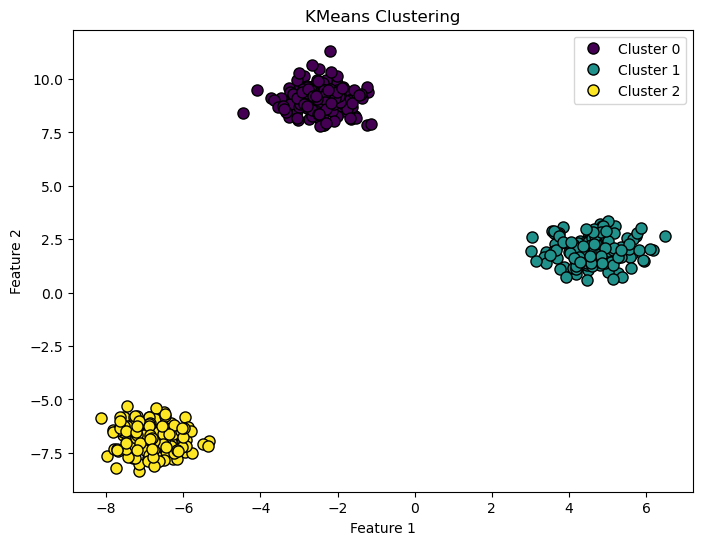

In [19]:
#visualizing clusters
plt.figure(figsize=(8,6))
unique_labels = set(labels)
colors = [plt.cm.viridis(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    plt.plot(X[labels == k, 0], X[labels == k, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=8, label=f'Cluster {k}')
plt.title('KMeans Clustering')
plt.xlabel('Feature 1') 
plt.ylabel('Feature 2')
plt.legend()
plt.show()


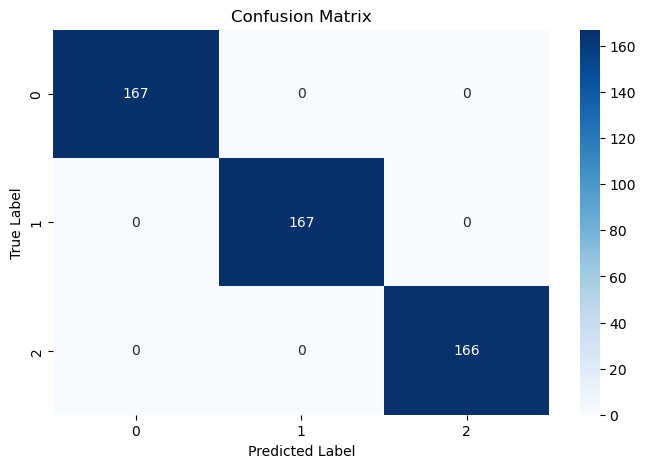

In [15]:
#visualizing confusion matrix and classification report
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
